# Practica de laboratorio 3

## Juan Mario Sosa Romo - 320051926

14/04/26

Ejecutar esta para tener ket y bra

$$
\newcommand{\ket}[1]{\left| #1 \right\rangle}
\newcommand{\bra}[1]{\left\langle #1 \right|}
\newcommand{\braket}[2]{\left\langle #1 \middle| #2 \right\rangle}
$$


In [28]:
!pip install qiskit
!pip install qiskit_aer

In [29]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

### **1. Bernstein-Vazirani**

**(a) (12.5 pts)** **Demostrar la identidad de las matrices Hadamards:**
$$H^{\otimes n}|x\rangle=\frac{1}{\sqrt{2^{n}}}\sum_{z\in\{0,1\}^{n}}(-1)^{x\cdot z}|z\rangle$$


**Demostracion por inducción**

1. **Caso base (n=1)**

Para un solo qubit $x \in \{0,1\}$:

- Para $x=0 ⇒ H \ket{0} = \frac{1}{\sqrt{2}} ((-1)^{0*0}\ket{0} + (-1)^{0*1}\ket{1}) = \frac{1}{\sqrt{2}} (\ket{0} +\ket{1}) = \ket{+}$
- Para $x=1 ⇒ H \ket{1} = \frac{1}{\sqrt{2}} ((-1)^{1*0}\ket{0} + (-1)^{1*1}\ket{1}) = \frac{1}{\sqrt{2}} (\ket{0} - \ket{1}) = \ket{-}$

2. **Hipotesis inductiva (n)**

Asumimos que la identidad es cierta para un sistema de $n$ qubits, es decir $x \in \{0,1\}^n$:

$$
H^{\otimes n}|x\rangle=\frac{1}{\sqrt{2^{n}}}\sum_{z\in\{0,1\}^{n}}(-1)^{x\cdot z}|z\rangle
$$

3. **Paso inductivo (n+1)**

P.D. La propiedad se mantiene para $n+1$ qubits. Tomamos un estado $x \in  \{0,1\}^{n+1}$ y factorizamos en $n$ qubits y uno por separado.

$$
H^{ \otimes n+1} \ket{x} = (H^{\otimes n} \otimes H)(\ket{x_1,\cdots, x_n} \otimes \ket{x_{n+1}}) = H^{\otimes n} \ket{x_1,\cdots, x_n} \otimes H\ket{x_{n+1}}
$$

Aplicamos H.D.I.

\begin{align*}
\frac{1}{\sqrt{2^{n}}}\sum_{z\in\{0,1\}^{n}}(-1)^{x\cdot z}|z \rangle \otimes \frac{1}{\sqrt{2}} \sum_{z \in \{0,1\}} (-1)^{(x_{n+1}) \cdot z } \ket{z}  &= \frac{1}{\sqrt{2^{n+1}}} \sum_{z' \in \{0,1\}^{n+1}} (-1)^{x \cdot z'} \ket{z'}
\end{align*}

$\blacksquare$

**Usando la fórmula anterior, explicar en tus propias palabras cómo aplicar $n$ compuertas Hadamard a los primeros $n$ qubits nos recupera el ket $s$ en la operación:**
$$|\psi_{3}\rangle=H^{\otimes n}|\psi_{2}\rangle=H^{\otimes n}\frac{1}{\sqrt{2^{n}}}\sum_{x\in\{0,1\}^{n}}(-1)^{x\cdot s}|x\rangle=|s\rangle$$

Por la identidad anterior tenemos que:

$$
\ket{\psi_2} = \frac{1}{\sqrt{2^{n}}}\sum_{x\in\{0,1\}^{n}}(-1)^{x\cdot s}|x\rangle = H^{\otimes n}\ket{s}
$$

Sustituyendo esto en la operacion final y recordando que la matriz Hadamard es su propia inversa obtenemos:

$$
\ket{\psi_3} = H^{\otimes n} H^{\otimes n}\ket{s} = (H^{\otimes n} H^{\otimes n})\ket{s} = I^{\otimes n} \ket{s} = \ket{s}
$$

Intuitivamente,la última capa de compuertas Hadamard invierte la superposición inicial, Las fases introducidas previamente por el oráculo provocan interferencia destructiva para todos los estados ortogonales a $\ket{s}$.

$\blacksquare$


**(b) (12.5 pts)** **¿Es el oráculo de Bernstein-Vazirani igual a aplicar una función balanceada en el algoritmo de Deutsch-Jozsa? ¿Sí, no, por qué?**

No, contraejemplo:

Tenemos el oraculo de Bernstein-Vazirani $f(x)=x \cdot s \ (mod 2)$, ahora si $s= 0^n$, $f(x) = 0  \  \forall \ x$ esto es una funcion constante no una balanceada por tanto es falso.

Se puede demostrar que para casos donde $s \not = 0^n$ es una función balanceada y por tanto vemos que el oraculo es un caso particular de las funciones balanceadas aceptadas por DJ.

$\blacksquare$

**(c) (12.5 pts)** **Analiza cómo funciona la función `bv_oracle(n, s)` y explica su funcionamiento en tus propias palabras con el circuito de Bernstein-Vazirani.**

La función `bv_oracle(n, s)` construye el operador unitario $U_f$ que evalúa la función $f(x) = s \cdot x \pmod 2$. Su funcionamiento se basa enteramente en explotar el efecto de phase kickback.

**1. Definición matemática del oráculo:**
Por definición, el oráculo actúa sobre un registro de entrada $|x\rangle$ y un qubit auxiliar $|y\rangle$:
$$U_f |x\rangle|y\rangle = |x\rangle|y \oplus (s \cdot x)\rangle$$

En este algoritmo preparamos el qubit auxiliar en el estado $|-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}$. Al aplicarle el oráculo a este estado, el resultado matemático es que la respuesta de la función se codifica como una fase en el registro de entrada:
$$U_f |x\rangle|-\rangle = (-1)^{s \cdot x} |x\rangle|-\rangle$$

**2. Construcción física con compuertas:**
El producto punto es una suma: $s \cdot x = (s_0 x_0 + s_1 x_1 + \dots + s_{n-1} x_{n-1}) \pmod 2$. Matemáticamente, solo los términos donde $s_i = 1$ afectan el resultado final.
Por lo tanto, la función `bv_oracle` recorre la cadena $s$. Por cada bit $s_i = 1$, coloca una compuerta CNOT donde el qubit de entrada $x_i$ es el control y el qubit auxiliar es el objetivo.

**3. La mecánica del Kickback:**
Esto funciona por cómo interactúa la compuerta CNOT con el estado $|-\rangle$ en el objetivo:
* Si el qubit de control $x_i$ está en $|0\rangle$, la compuerta no hace nada: el estado queda con fase positiva $(-1)^0$.
* Si el qubit de control $x_i$ está en $|1\rangle$, la compuerta invierte el $|-\rangle$, lo cual equivale a multiplicar el estado global por $-1$: fase negativa $(-1)^1$.

Dado que el registro de entrada está en una superposición de todos los $|x\rangle$ posibles (por las compuertas Hadamard previas), cada CNOT controlada inyecta una fase de $-1$ únicamente en los componentes de la superposición donde $x_i = 1$. Al aplicar todas las CNOTs correspondientes a los unos de $s$, las fases se multiplican, lo que en los exponentes es una suma, logrando exactamente el factor global $(-1)^{s \cdot x}$.

**Programa el algoritmo de Bernstein-Vazirani SIN USAR LA FUNCIÓN `bv_oracle(n, s)` para los siguientes strings, explicando en el código lo que hiciste**:
* $s=0110$
* $s=1101$
* $s=1111$
* $s=1010$

In [30]:
def run_bv_algorithm(s):
    """
    Construye y ejecuta el circuito de Bernstein-Vazirani para un string s dado,
    """
    n = len(s)
    # Creamos un circuito con n qubits de entrada y 1 qubit auxiliar, más n bits clásicos
    qc = QuantumCircuit(n + 1, n)

    # 1. Preparación del estado inicial: |0...>|1>
    qc.x(n) # Ponemos el qubit auxiliar en el estado |1>

    # 2. Aplicamos Hadamard a todos los qubits
    # Esto crea la superposición en la entrada y pone al auxiliar en el estado |-> para el phase kickback
    qc.h(range(n + 1))
    qc.barrier()

    # 3. ORÁCULO DE BERNSTEIN-VAZIRANI
    # Recorremos el string s.
    # Little-endian: el qubit i controla la compuerta si el bit en la posición (n-1-i) del string es '1'.
    for i in range(n):
        if s[n - 1 - i] == '1':
            qc.cx(i, n) # Control: i de entrada, Target: qubit auxiliar
    qc.barrier()

    # 4. H a entrada para interferencia
    qc.h(range(n))

    # 5. Medición
    qc.measure(range(n), range(n))

    # Simulación local perfecta
    simulator = AerSimulator()
    result = simulator.run(qc, shots=100).result()
    # BV es determinista (P=1), así que 1 shot basta.
    # Usamos más shots solo para validar que no hay errores en la implementación.
    counts = result.get_counts()

    print(f"String secreto ingresado: {s} -> String recuperado por medición: {list(counts.keys())[0]}")
    print(qc.draw())
    return qc, counts

for s in ['0110', '1101', '1111', '1010']:
    run_bv_algorithm(s)

String secreto ingresado: 0110 -> String recuperado por medición: 0110
     ┌───┐      ░            ░ ┌───┐┌─┐         
q_0: ┤ H ├──────░────────────░─┤ H ├┤M├─────────
     ├───┤      ░            ░ ├───┤└╥┘┌─┐      
q_1: ┤ H ├──────░───■────────░─┤ H ├─╫─┤M├──────
     ├───┤      ░   │        ░ ├───┤ ║ └╥┘┌─┐   
q_2: ┤ H ├──────░───┼────■───░─┤ H ├─╫──╫─┤M├───
     ├───┤      ░   │    │   ░ ├───┤ ║  ║ └╥┘┌─┐
q_3: ┤ H ├──────░───┼────┼───░─┤ H ├─╫──╫──╫─┤M├
     ├───┤┌───┐ ░ ┌─┴─┐┌─┴─┐ ░ └───┘ ║  ║  ║ └╥┘
q_4: ┤ X ├┤ H ├─░─┤ X ├┤ X ├─░───────╫──╫──╫──╫─
     └───┘└───┘ ░ └───┘└───┘ ░       ║  ║  ║  ║ 
c: 4/════════════════════════════════╩══╩══╩══╩═
                                     0  1  2  3 
String secreto ingresado: 1101 -> String recuperado por medición: 1101
     ┌───┐      ░                 ░ ┌───┐┌─┐         
q_0: ┤ H ├──────░───■─────────────░─┤ H ├┤M├─────────
     ├───┤      ░   │             ░ ├───┤└╥┘┌─┐      
q_1: ┤ H ├──────░───┼─────────────░─┤ H ├─╫─┤M├──────
     

**(d) (Opcional) (+40 pts en cualquier práctica de la 1 a la 3):** ¿Puedes replicar el mismo algoritmo en Pennylane? ¿Qué necesitarías para hacerlo? Implementa V-B en Pennylane desde 0 y explica en un breve video cómo funciona el algoritmo, cómo lo programaste, cuál fue el oráculo que usaste y si funcionó. Si lo haces explícame en qué práctica te gustaría recuperar puntos.

---

### 2. Simon

**(a) (12.5 pts)** **Demuestra que si tenemos una función 2-a-1 del tipo que Simon estudia, de modo que $f(x)=f(x\oplus s)$ para algún string $s$ dado, entonces dados $x$ e $y$ tales que $f(x)=f(y)$, con $x\neq y$, entonces $x\oplus y=s$. Explica cómo usamos esta propiedad para resolver el problema de Simon de forma clásica.**

**1. Demostración de $x \oplus y = s$ y su uso clásico**

Sabemos por definición que la función es 2-a-1 y cumple $f(x) = f(x \oplus s)$. Si encontramos dos entradas distintas $x \neq y$ tales que $f(x) = f(y)$, la única forma en que esto ocurre bajo la estructura de Simon es que ambas entradas estén separadas por el string $s$.

Es decir, $y = x \oplus s$.
Para despejar $s$, aplicamos la operación XOR con $x$ en ambos lados de la igualdad:
$$x \oplus y = x \oplus (x \oplus s)$$

Como el XOR es asociativo y aplicar XOR sobre sí mismo resulta en un string de ceros ($x \oplus x = 0^n$):
$$x \oplus y = 0^n \oplus s = s$$

**Uso clásico:**
De forma clásica, resolvemos el problema de Simon buscando colisiones a fuerza bruta. Evaluamos $f(x)$ para entradas aleatorias hasta encontrar un par $x \neq y$ donde $f(x) = f(y)$. Una vez hallado, simplemente calculamos $s = x \oplus y$. Para garantizar la colisión, en el peor caso debemos evaluar $2^{n-1}+1$ entradas, lo cual requiere un tiempo exponencial $\mathcal{O}(2^{n/2})$ y es ineficiente.

**Demuestra que $(z \oplus s) \cdot y = (z \cdot y) \oplus (s \cdot y)$. Con eso completa la parte de la demostración de Simon que faltaba en el notebook y explica por qué los strings $y$ que recuperas cumplen que $s\cdot y=0$ cuando corres el algoritmo de Simon y lees el primer registro. Las definiciones de $(x\oplus y)$ y $(x\cdot y)$ se encuentran en el notebook.**

**Prueba de la propiedad distributiva**

Sean $z, s, y \in \{0, 1\}^n$. Definimos el producto punto en $\mathbb{F}_2$ como $a \cdot y = \left( \sum_{i=1}^n a_i y_i \right) \pmod 2$ y la suma bit a bit (XOR) como $(z \oplus s)_i = (z_i + s_i) \pmod 2$.

**P.D:**
$$(z \oplus s) \cdot y = (z \cdot y) \oplus (s \cdot y)$$

**Demostración:**
Por definición de producto punto:
$$(z \oplus s) \cdot y = \bigoplus_{i=1}^n (z \oplus s)_i y_i = \bigoplus_{i=1}^n (z_i \oplus s_i) y_i$$

En el cuerpo $\mathbb{F}_2$, la operación XOR ($\oplus$) es la suma y la multiplicación es la estándar. Aplicamos la distributividad escalar de la multiplicación sobre la suma en $\mathbb{F}_2$:
$$(z_i \oplus s_i) y_i = (z_i y_i \oplus s_i y_i)$$

Sustituyendo esto en la sumatoria original:
$$(z \oplus s) \cdot y = \bigoplus_{i=1}^n (z_i y_i \oplus s_i y_i)$$

Debido a que la suma en $\mathbb{F}_2$ es asociativa y conmutativa, podemos reordenar los términos para agrupar las componentes de $z$ y $s$ por separado:
$$(z \oplus s) \cdot y = \left( \bigoplus_{i=1}^n z_i y_i \right) \oplus \left( \bigoplus_{i=1}^n s_i y_i \right)$$

Por definición de producto punto, cada término entre paréntesis corresponde a $(z \cdot y)$ y $(s \cdot y)$ respectivamente:
$$(z \oplus s) \cdot y = (z \cdot y) \oplus (s \cdot y) \quad \blacksquare$$

**Completando la demostración de Simon**

El estado del sistema antes de la medición del primer registro es:
$$\ket{\psi} = \frac{1}{2^n} \sum_{y \in \{0,1\}^n} \left( \sum_{x \in \{0,1\}^n} (-1)^{x \cdot y} \ket{y} \ket{f(x)} \right)$$

Dado que la función $f$ cumple $f(x) = f(x \oplus s)$, para cada valor $k$ en el rango de $f$, existen exactamente dos preimágenes: $z$ y $z \oplus s$. Agrupamos la suma sobre $x$ en pares que mapean al mismo estado $\ket{f(z)}$:
$$\text{Amplitud de } \ket{y} \ket{f(z)} = \frac{1}{2^n} \left( (-1)^{z \cdot y} + (-1)^{(z \oplus s) \cdot y} \right)$$

Usando la propiedad distributiva demostrada arriba:
$$\frac{1}{2^n} \left( (-1)^{z \cdot y} + (-1)^{(z \cdot y) \oplus (s \cdot y)} \right) = \frac{1}{2^n} \left( (-1)^{z \cdot y} + (-1)^{z \cdot y} (-1)^{s \cdot y} \right)$$
$$= \frac{(-1)^{z \cdot y}}{2^n} \left( 1 + (-1)^{s \cdot y} \right)$$

**Análisis de la interferencia**
Para determinar qué vectores $y$ tienen probabilidad de ser observados, analizamos el factor $\left( 1 + (-1)^{s \cdot y} \right)$:

1. **Interferencia destructiva:** Si $s \cdot y = 1 \pmod 2$, entonces $(-1)^{s \cdot y} = -1$.
   La amplitud resulta en $\frac{(-1)^{z \cdot y}}{2^n} (1 - 1) = 0$.
   La probabilidad de medir estos strings es nula.

2. **Interferencia constructiva:** Si $s \cdot y = 0 \pmod 2$, entonces $(-1)^{s \cdot y} = 1$.
   La amplitud resulta en $\frac{(-1)^{z \cdot y}}{2^n} (2) = \frac{(-1)^{z \cdot y}}{2^{n-1}}$.
   La probabilidad de medir estos strings es positiva.

**Conclusión**
Al correr el algoritmo de Simon y realizar la medición del primer registro, la naturaleza probabilística de la mecánica cuántica garantiza que solo colapsaremos en estados cuya amplitud sea distinta de cero. Como hemos demostrado, cualquier string $y$ tal que $s \cdot y = 1$ sufre una cancelación perfecta de sus fases (interferencia destructiva), haciendo imposible su lectura. Por lo tanto, cualquier string $y$ recuperado por el algoritmo necesariamente debe cumplir la condición de ortogonalidad:
$$s \cdot y = 0 \pmod 2$$


**(b) (12.5 pts)** **Piensa en 3 funciones 2-a-1 para los siguientes 3 strings:**
* $s=1010$
* $s=1101$
* $s=1111$

**Fabrica el oráculo de las mismas (Recuerda que $CNOT(x,y)=(x,y\oplus x)$). Recupera los strings utilizando Simon y resuelve el sistema de ecuaciones con el método que tú quieras. No olvides que Qiskit invierte el orden de los strings.**

Para construir las 3 funciones, utilizamos el circuito que copia la entrada a la salida ($\ket{x} \to \ket{x}$) y luego, usando como control el bit más significativo donde $s=1$ (denotémoslo $x_m$), aplicamos un XOR (CNOT) a todos los bits de salida donde $s_i = 1$. Asumimos la convención Little-Endian de Qiskit ($x_3 x_2 x_1 x_0$).

**1. Para $s = 1010$ ($s_3=1, s_1=1$, bit de control $x_3$):**
La función matemática es:
$$f(x) = (x_3 \oplus x_3, x_2, x_1 \oplus x_3, x_0) = (0, x_2, x_1 \oplus x_3, x_0)$$

*Supongamos que al correr el algoritmo recuperamos los strings linealmente independientes:* `0101`, `1111`, `1010`.
Formulamos $y \cdot s = 0 \implies y_3 s_3 \oplus y_2 s_2 \oplus y_1 s_1 \oplus y_0 s_0 = 0$:
1. $y = 0101 \implies s_2 \oplus s_0 = 0 \implies s_2 = s_0$
2. $y = 1111 \implies s_3 \oplus s_2 \oplus s_1 \oplus s_0 = 0$
3. $y = 1010 \implies s_3 \oplus s_1 = 0 \implies s_3 = s_1$

Sustituyendo (1) en (2): $s_3 \oplus s_0 \oplus s_1 \oplus s_0 = 0 \implies s_3 \oplus s_1 = 0$, que es redundante con (3).
Para obtener la solución no trivial ($s \neq 0000$), fijamos la variable libre $s_3 = 1$, lo que implica $s_1 = 1$. Como el string debe ser distinto de 0 y no afectar $s_3, s_1$, fijamos $s_0 = 0 \implies s_2 = 0$.
**Resultado:** $s = 1010$.

***

**2. Para $s = 1101$ ($s_3=1, s_2=1, s_0=1$, bit de control $x_3$):**
La función matemática es:
$$f(x) = (x_3 \oplus x_3, x_2 \oplus x_3, x_1, x_0 \oplus x_3) = (0, x_2 \oplus x_3, x_1, x_0 \oplus x_3)$$

*Supongamos que recuperamos los strings:* `0010`, `1001`, `0101`.
1. $y = 0010 \implies 0s_3 \oplus 0s_2 \oplus 1s_1 \oplus 0s_0 = 0 \implies s_1 = 0$
2. $y = 1001 \implies 1s_3 \oplus 0s_2 \oplus 0s_1 \oplus 1s_0 = 0 \implies s_3 \oplus s_0 = 0 \implies s_3 = s_0$
3. $y = 0101 \implies 0s_3 \oplus 1s_2 \oplus 0s_1 \oplus 1s_0 = 0 \implies s_2 \oplus s_0 = 0 \implies s_2 = s_0$

De (1) sabemos que $s_1 = 0$. De (2) y (3) vemos que $s_3 = s_2 = s_0$. Para la solución no trivial, hacemos $s_0 = 1$.
Esto implica $s_3 = 1$ y $s_2 = 1$.
**Resultado:** $s = 1101$.

***

**3. Para $s = 1111$ ($s_3=1, s_2=1, s_1=1, s_0=1$, bit de control $x_3$):**
La función matemática es:
$$f(x) = (0, x_2 \oplus x_3, x_1 \oplus x_3, x_0 \oplus x_3)$$

*Supongamos que recuperamos los strings:* `1100`, `0110`, `0011`.
1. $y = 1100 \implies s_3 \oplus s_2 = 0 \implies s_3 = s_2$
2. $y = 0110 \implies s_2 \oplus s_1 = 0 \implies s_2 = s_1$
3. $y = 0011 \implies s_1 \oplus s_0 = 0 \implies s_1 = s_0$

Por transitividad: $s_3 = s_2 = s_1 = s_0$. Para la solución no trivial, todas las variables deben ser 1.
**Resultado:** $s = 1111$.

In [31]:
def run_simon(s):
    n = len(s)

    # Registros: n para entrada, n para salida y n clásicos para medición
    qr_in = QuantumRegister(n, 'in')
    qr_out = QuantumRegister(n, 'out')
    cr = ClassicalRegister(n, 'meas')
    qc = QuantumCircuit(qr_in, qr_out, cr)

    # 1. Aplicamos H a entrada
    qc.h(qr_in)
    qc.barrier()

    # Copiamos el registro de entrada al de salida
    for i in range(n):
        qc.cx(qr_in[i], qr_out[i])

    # Encontramos el índice 'm' del primer bit en 's' que sea '1'
    # Qiskit usa Little-Endian
    m = None
    for i in range(n):
        if s[n - 1 - i] == '1':
            m = i
            break

    # Generamos la colisión f(x) = f(x ⊕ s)
    # Aplicamos CNOT desde el qubit 'm' a todos los qubits de salida donde s_i == 1
    if m is not None:
        for i in range(n):
            if s[n - 1 - i] == '1':
                qc.cx(qr_in[m], qr_out[i])
    qc.barrier()

    # Interferencia final aplicando Hadamard
    qc.h(qr_in)

    # Medimos
    qc.measure(qr_in, cr)

    # 5. Simulación
    sim = AerSimulator()
    qc_transpiled = transpile(qc, sim)
    result = sim.run(qc_transpiled, shots=1024).result()
    counts = result.get_counts()

    print(f"Resultados de medición para el string secreto s = {s}:")
    print(counts)
    print("=" * 60)

    return counts

for s in ['1010', '1101', '1111']:
    run_simon(s)

Resultados de medición para el string secreto s = 1010:
{'1010': 122, '1011': 123, '0000': 141, '0101': 122, '1110': 129, '1111': 126, '0001': 112, '0100': 149}
Resultados de medición para el string secreto s = 1101:
{'0101': 133, '1110': 115, '0111': 126, '1011': 122, '0010': 122, '0000': 134, '1001': 127, '1100': 145}
Resultados de medición para el string secreto s = 1111:
{'0011': 117, '0101': 119, '1111': 142, '0110': 109, '1100': 125, '1001': 137, '1010': 135, '0000': 140}


**(c) (12.5 pts)** **Explica qué hace la función `simon_oracle(s)` del notebook y por qué siempre nos recupera un oráculo 2-a-1 y qué hace si el string $s$ solo tiene 0. Explícalo en tus propias palabras y haz la demostración matemática.**

```Python
def simon_oracle(s):
    n = len(s)
    oracle = QuantumCircuit(2*n)
    
    # copiar x en el registro de salida
    for i in range(n):
        oracle.cx(i, i+n)

    # introducir la dependencia con s
    for i, bit in enumerate(s):
        if bit == '1':
            oracle.cx(0, i+n)

    return oracle
```

**Funcionamiento del circuito:**

La función construye el oráculo en dos fases. Primero, utiliza una capa de compuertas CNOT para copiar el estado exacto del registro de entrada en el registro de salida. Segundo, utiliza el qubit de entrada `0` (denotémoslo $x_0$) como el único qubit de control maestro. Recorre el string secreto $s$ y, si encuentra un '1' en la posición $i$, coloca una CNOT desde $x_0$ hacia el qubit $i$ del registro de salida.

En resumen: si el qubit $x_0$ es 0, la salida es igual a la entrada ($x$). Si el qubit $x_0$ es 1, la salida es la entrada con un XOR aplicado en las posiciones donde $s$ vale 1 ($x \oplus s$).

**Demostración matemática (¿Por qué es 2-a-1?):**

Matemáticamente, la función que este circuito implementa se define como:
$$f(x) = x \oplus (x_0 \cdot s)$$

Para que sea una función 2-a-1 válida para el problema de Simon, debemos demostrar que $f(x) = f(x \oplus s)$. Evaluamos la función con la entrada $x \oplus s$:
$$f(x \oplus s) = (x \oplus s) \oplus ((x \oplus s)_0 \cdot s)$$

Sabemos que el bit en la posición 0 de la suma es $(x \oplus s)_0 = x_0 \oplus s_0$. Sustituyendo esto en la ecuación:
$$f(x \oplus s) = x \oplus s \oplus ((x_0 \oplus s_0) \cdot s)$$

**Nota de rigor matemático:**

El código *solo* genera un oráculo 2-a-1 si asumimos estrictamente que $s_0 = 1$ (el bit de control coincide con un '1' en el string secreto). Si asumimos $s_0 = 1$, la demostración se completa así:
$$f(x \oplus s) = x \oplus s \oplus ((x_0 \oplus 1) \cdot s)$$

Aplicamos la distributiva en módulo 2:
$$f(x \oplus s) = x \oplus s \oplus (x_0 \cdot s) \oplus (1 \cdot s)$$
$$f(x \oplus s) = x \oplus s \oplus (x_0 \cdot s) \oplus s$$

Como cualquier string aplicado con XOR sobre sí mismo se anula ($s \oplus s = 0^n$), podemos reorganizar:
$$f(x \oplus s) = x \oplus (x_0 \cdot s) = f(x)$$

Esto demuestra que, asumiendo $s_0 = 1$, las entradas $x$ y $x \oplus s$ colisionan siempre en la misma salida.

**¿Qué hace si el string $s$ solo tiene 0 ($s = 0^n$)?**

Si $s = 00\dots0$, la condición interna `if bit == '1'` nunca evalúa a verdadero. Por lo tanto, el segundo bucle `for` no inserta ninguna compuerta en el circuito.

El oráculo se reduce exclusivamente al primer bucle, cuya operación es:
$$f(x) = x$$

Bajo esta condición, la función deja de ser 2-a-1 y se convierte en una función **1-a-1** (estrictamente biyectiva o identidad). Cada entrada distinta genera una salida única. Esto tiene coherencia matemática total con el problema de Simon: un periodo de $s=0^n$ significa que $f(x) = f(y) \iff x \oplus y = 0^n \iff x = y$, lo que describe exactamente una función 1-a-1.

**(d) (12.5 pts)** **Genera 2 oráculos de funciones 1-a-1 y corrobora que Simon nos regresa todos los strings con igual probabilidad, y compara con 2 oráculos de funciones 2-a-1 (puedes usar los que ya están en el notebook). Puedes hacerlo de la forma que tú quieras, pero te recomiendo que hagas histogramas de las mediciones que recuperaste para comparar los datos de las mediciones. Coloca el código del algoritmo, del oráculo y de todas las gráficas de forma ordenada y clara.**


**Oráculos 1-a-1:**

Una función 1-a-1 asigna cada entrada única a una salida única. En el contexto de Simon, esto equivale a tener un periodo $s = 00\dots0$. Implementaremos dos oráculos 1-a-1:
* **Oráculo Identidad:** $f(x) = x$. Simplemente copia la entrada a la salida.
* **Oráculo Inversor:** $f(x) = \neg x$. Invierte todos los bits de la entrada.

**Oráculos 2-a-1:**

Reutilizaremos la lógica general que construimos en el inciso 2(b) para generar funciones donde $f(x) = f(x \oplus s)$ para un string $s$ dado. Usaremos $s = 1010$ y $s = 1111$.

**Expectativa Teórica:**

* **Para funciones 1-a-1 ($s=0^n$):** El algoritmo de Simon evalúa $y \cdot s = y \cdot 0^n = 0$. Como esto se cumple para *cualquier* string $y$, la interferencia no elimina ningún estado. Deberíamos medir todos los $2^n$ strings posibles con probabilidad aproximadamente igual.
* **Para funciones 2-a-1 ($s \neq 0^n$):** El algoritmo restringe los resultados a los strings $y$ que cumplen $y \cdot s = 0 \pmod 2$. Deberíamos medir exactamente la mitad de los strings posibles ($2^{n-1}$ strings), cada uno con probabilidad uniforme.

In [32]:
def oracle_1to1_identity(n):
    """Oráculo 1-a-1: f(x) = x (Identidad)"""
    qc = QuantumCircuit(2*n)
    for i in range(n):
        qc.cx(i, i+n)
    return qc

def oracle_1to1_invert(n):
    """Oráculo 1-a-1: f(x) = NOT x"""
    qc = QuantumCircuit(2*n)
    # Primero copiamos
    for i in range(n):
        qc.cx(i, i+n)
    # Luego invertimos la salida
    for i in range(n):
        qc.x(i+n)
    return qc

def oracle_2to1_general(s):
    """Oráculo 2-a-1 general (basado en inciso 2b)"""
    n = len(s)
    qc = QuantumCircuit(2*n)
    # Copiamos
    for i in range(n):
        qc.cx(i, i+n)

    # Encontramos el bit de control m (Little-Endian)
    m = None
    for i in range(n):
        if s[n - 1 - i] == '1':
            m = i
            break

    # Aplicamos la colisión
    if m is not None:
        for i in range(n):
            if s[n - 1 - i] == '1':
                qc.cx(m, i+n)
    return qc

In [33]:
def run_simon_with_oracle(oracle, n, shots=10000):
    """Ejecuta el algoritmo de Simon recibiendo el oráculo ya construido"""
    qr_in = QuantumRegister(n, 'in')
    qr_out = QuantumRegister(n, 'out')
    cr = ClassicalRegister(n, 'meas')
    qc = QuantumCircuit(qr_in, qr_out, cr)

    # 1. Superposición inicial
    qc.h(qr_in)
    qc.barrier()

    # 2. Aplicar el Oráculo
    qc.compose(oracle, inplace=True)
    qc.barrier()

    # 3. Interferencia final
    qc.h(qr_in)

    # 4. Medición
    qc.measure(qr_in, cr)

    # Simulación
    sim = AerSimulator()
    qc_transpiled = transpile(qc, sim)
    result = sim.run(qc_transpiled, shots=shots).result()
    return result.get_counts()

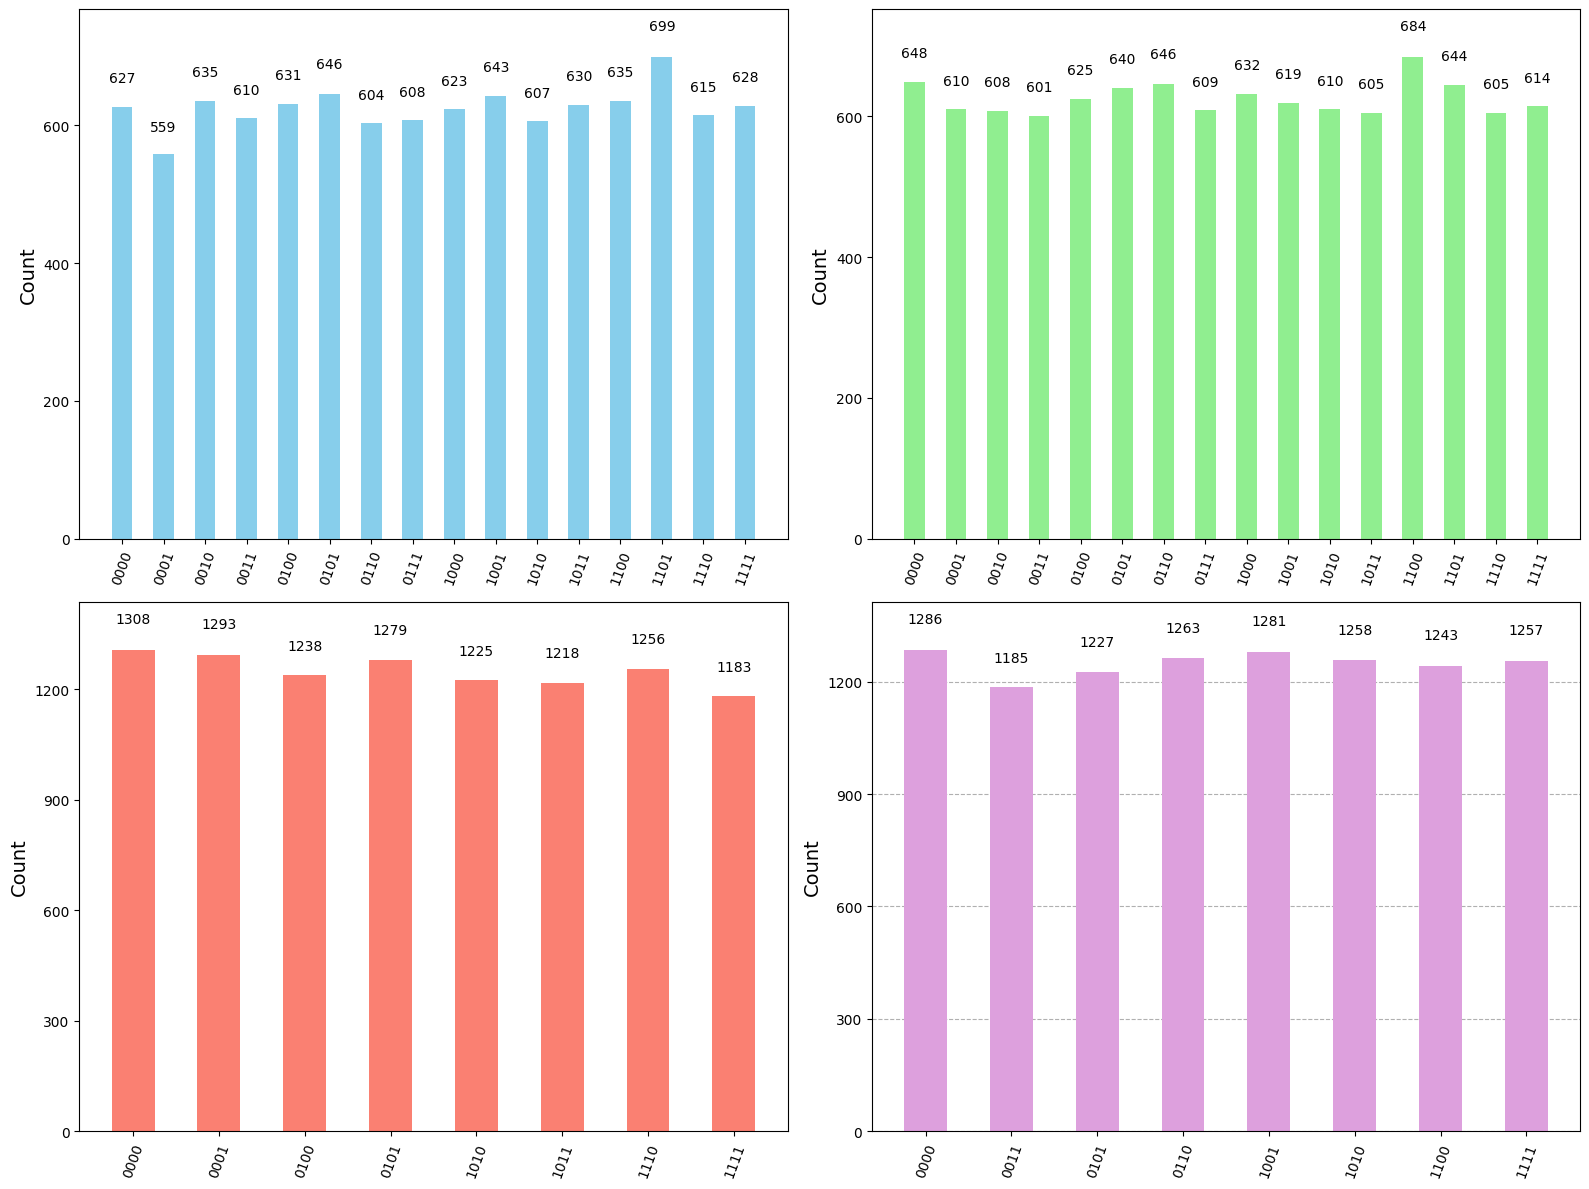

--- Análisis de Resultados ---
Para funciones 1-a-1: Deberíamos ver barras para los 16 estados posibles.
Strings medidos (Identidad): 16
Strings medidos (Inversor): 16

Para funciones 2-a-1: Deberíamos ver barras solo para 8 estados posibles.
Strings medidos (s=1010): 8
Strings medidos (s=1111): 8


In [34]:
n = 4

# Oráculos 1-a-1
counts_id = run_simon_with_oracle(oracle_1to1_identity(n), n)
counts_inv = run_simon_with_oracle(oracle_1to1_invert(n), n)

# Oráculos 2-a-1
s1 = '1010'
s2 = '1111'
counts_2to1_a = run_simon_with_oracle(oracle_2to1_general(s1), n)
counts_2to1_b = run_simon_with_oracle(oracle_2to1_general(s2), n)

# Graficar
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plot_histogram(counts_id, ax=axes[0,0], color='skyblue')
plot_histogram(counts_inv, ax=axes[0,1], color='lightgreen')
plot_histogram(counts_2to1_a, ax=axes[1,0], color='salmon')
plot_histogram(counts_2to1_b, ax=axes[1,1], color='plum')
plt.tight_layout()
plt.show()

print("--- Análisis de Resultados ---")
print(f"Para funciones 1-a-1: Deberíamos ver barras para los {2**n} estados posibles.")
print(f"Strings medidos (Identidad): {len(counts_id)}")
print(f"Strings medidos (Inversor): {len(counts_inv)}")

print(f"\nPara funciones 2-a-1: Deberíamos ver barras solo para {2**(n-1)} estados posibles.")
print(f"Strings medidos (s={s1}): {len(counts_2to1_a)}")
print(f"Strings medidos (s={s2}): {len(counts_2to1_b)}")


---

### 3. NISQ (12.5 pts)
**Investiga qué significa el término Noisy Intermediate-Scale Quantum y contesta las siguientes preguntas:**

**(a) ¿Qué caracteriza a las computadoras cuánticas de la era NISQ?**

El término describe el estado físico de la infraestructura cuántica actual.
* **Noisy (Ruidosas):** Operan sin tolerancia a fallos (carecen de corrección de errores cuánticos). Las compuertas tienen baja fidelidad y son altamente susceptibles al ruido térmico y electromagnético.
* **Intermediate-Scale (Escala Intermedia):** Disponen de un volumen de qubits (entre 50 y pocos cientos) suficiente para superar la simulación clásica, pero insuficiente para abstraer qubits lógicos perfectos a partir de miles de qubits físicos.
* **Topología física restringida:** La conectividad no es global. Los qubits solo pueden interactuar con vecinos físicos inmediatos, obligando a introducir operaciones de ruteo (compuertas SWAP) que degradan la señal.

**(b) ¿Por qué el ruido y la decoherencia afectan el funcionamiento de los algoritmos cuánticos?**

La decoherencia es la pérdida de aislamiento del sistema cuántico frente a su entorno, lo que destruye los estados de superposición prematuramente. Además, el ruido en las compuertas inyecta errores aleatorios de bit y de fase. Dado que algoritmos como Bernstein-Vazirani y Simon dependen matemáticamente de una orquestación perfecta de interferencias constructivas y destructivas, cualquier alteración en las fases corrompe las cancelaciones matemáticas, devolviendo ruido blanco en el registro final.

**(c) Considerando el número de qubits y las compuertas que utilizan, ¿qué tan factible es correr los algoritmos de Bernstein-Vazirani y de Simon en computadoras NISQ?**

* **Bernstein-Vazirani:** Es factible para un $n$ moderado. Su demanda espacial es baja ($n+1$ qubits) y su profundidad temporal es constante $O(1)$. Al requerir solo una capa de Hadamard y una evaluación del oráculo, se ejecuta rápidamente antes de que los tiempos de decoherencia ($T_1$ y $T_2$) del hardware colapsen el estado.
* **Simon:** Es poco factible y escala muy mal. Duplica la demanda de memoria operativa ($2n$ qubits) y el oráculo requiere mapeos 2-a-1 usando compuertas CNOT entre registros enteros. Esta profundidad temporal $O(n)$ garantiza que la tasa de error se acumule de manera multiplicativa, destruyendo el entrelazamiento mucho antes de finalizar el cómputo.

**(d) ¿Cuál de los dos algoritmos crees que sería más robusto frente al ruido y por qué?**

Bernstein-Vazirani es significativamente más robusto. Minimizar la profundidad del circuito es el principio base de la confiabilidad en sistemas NISQ. BV procesa un circuito superficial con dependencias directas. En Simon, forzar compuertas CNOT entre $2n$ qubits obliga a realizar operaciones entre qubits que físicamente están lejanos en el procesador. El compilador debe insertar rutinas de SWAP para acercarlos, lo que dispara una cascada de fallos sistémicos irrecuperables.

**(e) Investiga un experimento real donde alguno de estos algoritmos haya sido implementado en hardware cuántico y describe brevemente el resultado.**

Un estudio experimental en procesadores superconductores evaluó el algoritmo de Bernstein-Vazirani en hardware real. Los resultados mostraron una fuerte degradación en la confiabilidad, con un éxito promedio de solo 26.4% frente al 100% en simulaciones ideales.

Se observó que el rendimiento depende fuertemente de la estructura del problema, en particular de la densidad del string secreto. Para patrones densos, la fidelidad del estado cuántico se degrada drásticamente, llegando a fallos completos en instancias de 10 qubits.

El estudio concluye que el rendimiento de los algoritmos cuánticos en hardware NISQ está altamente condicionado por la estructura del problema y por mecanismos de ruido que no son capturados adecuadamente por los modelos actuales.

Experimental Evaluation of the Bernstein-Vazirani Algorithm on Superconducting Quantum Processors. arXiv preprint arXiv:2511.14821, 2025.